In [ ]:
import requests 
census_api_key = '503a45c2c4a9be075f1f523252e01e7a305885a7'
url = "https://api.census.gov/data/2023/acs/acs5/subject?get=group(S1901)&ucgid=860Z200US10001,860Z200US10002"\
    .format(census_api_key)

response = requests.request("GET", url)
     

In [ ]:
response.status_code

In [ ]:
response.json()

In [ ]:
len(response.json()[0])

In [ ]:
import pandas as pd

######## features to consider... ########
#income by race 
#raw population counts (by race)
#proportion of homeowners (w/ a mortgage specifically)

population_map = {
    'TOTAL POPULATION ESTIMATE': 'B01001_001E', 
    'POPULATION W': 'B01001A_001E',
    'POPULATION B': 'B01001B_001E',
    'POPULATION AAPI': 'B01001D_001E',
    'POPULATION H': 'B01001I_001E',
    'MEDIAN_AGE': 'B01002_001E'

}

income_map = {
    'PER CAPITA INCOME': 'B19301_001E',
    'PER CAPITA INCOME W': 'B19301A_001E',
    'PER CAPITA INCOME B': 'B19301B_001E',
    'PER CAPITA INCOME AAPI': 'B19301D_001E',
    'PER CAPITA INCOME H': 'B19301I_001E',
    'PER CAPITA INCOME A15-24': 'B19049_002E',
    'PER CAPITA INCOME A25-44': 'B19049_003E',
    'PER CAPITA INCOME A45-64': 'B19049_004E',
    'PER CAPITA INCOME A65+': 'B19049_005E'
}

housing_mobility_map = {
    'TOTAL HH POP': 'B07013_001E',
    'SAME H 1 YR':'B07013_002E',
    'SAME STATE':'B07013_004E',
    'DIFFERENT STATE':'B07013_013E',
    'ABROAD': 'B07013_015E'
}

#ratio of mortaaged/non-mortgaged households? averaged LTV? use as indicators to describe aggregated credit status per zip  
#15 yr 30 yr mortgages not tracked 
#just assume 30 yr? 
#or estimate distribution based on global assumption 
#note, this data isn't available beyond 2023
credit_risk_vars = {
    'MORTGAGE': 'B25101_002E',
    'TOTAL': 'B25101_001E',
    'MEDIAN_HH_VALUE':'B25097_003E', 
    'MEDIAN_MONTHLY_MORTGAGE':'B25088_003E'
}

##### 

test_zip = 11101 
test_ucgid = '8600000US' + str(test_zip)
var_codes = ','.join(
   list(population_map.values()) \
  + list(income_map.values()) \
  + list(housing_mobility_map.values()) 
)

url = f'https://api.census.gov/data/2020/acs/acs5?get=NAME,{var_codes}&ucgid={test_ucgid}' 

response = requests.request("GET", url)

#why is no data being returned for any year not 2021-2023?? look into this
url


In [ ]:
response.status_code

In [ ]:
var_codes

In [ ]:
pd.DataFrame(
    data=response.json()[1],
    index=['ZCTA'] \
        + list(population_map.keys()) \
        + list(income_map.keys()) \
        + list(housing_mobility_map.keys()) 
        + ['ucgid'],
    columns=['attr']
)

In [ ]:
1501*30*12

In [ ]:
###### retrieve all ZCTAs based on what's in the Redfin dataset as a collection, and pass them as ucgis id's into the request 
!pip install duckdb
import duckdb 
from tqdm import tqdm 

con=duckdb.connect(
    '../datasets/combined_data2.db'
)

zips_FL = con.sql(
    '''
    select distinct zip from redfin_dataset where STATE_CODE = 'FL' 
    ;
    '''
).df()['zip']

headers = requests.utils.default_headers()
headers.update(
    {
        'User-Agent': 'PostmanRuntime/7.43.4',
    }
)

import numpy as np

years = np.arange(2021,2024)
blocks_it = np.arange(0,len(zips_FL),len(zips_FL)//10)
all_ = []

for year in tqdm(years):
    for idx, _ in list(enumerate(blocks_it))[:-1]:
        i_start = blocks_it[idx]
        i_end = blocks_it[idx+1]

        zips_block = zips_FL.loc[i_start:i_end]
        usgis_id_block = ','.join('860Z200US' + zips_block)
        url_block = f'https://api.census.gov/data/{year}/acs/acs5?get=NAME,{var_codes}&ucgid={usgis_id_block}' 
       

        response = requests.get(url_block, headers=headers)

        assert response.status_code == 200
    
        data = response.json() 

        values = data[1:]
        columns = ['ZCTA'] \
            + list(population_map.keys()) \
            + list(income_map.keys()) \
            + list(housing_mobility_map.keys()) \
            + ['ucgid']
        tbl = pd.DataFrame(data=values,columns=columns)
        tbl['year'] = int(year)
        tbl['zip']=tbl['ZCTA'].str.strip('ZCTA5 ')
        tbl = tbl.drop(columns=['ucgid','ZCTA'])
        tbl = tbl.astype(np.float64)
        all_.append(tbl)

sample_FL23 = pd.concat(all_)

sample_FL23.head(25)




In [ ]:
sample_FL23.columns

In [ ]:
con=duckdb.connect(
    '../datasets/combined_data2.db'
)

dd = con.sql('' \
'select * from fl_dataset;'
).df().drop_duplicates()

dd['test'] = dd.groupby(['zip'])['home_price'].diff() / dd.groupby(['zip'])['home_price'].shift(1)
dd


In [ ]:
dd.loc[dd['zip'] == 32081]

In [ ]:
dd.loc[dd['home_price'] == np.inf]

In [ ]:
import warnings
import pandas as pd 
import numpy as np 
import geopandas as gpd 
from scipy.stats import ranksums
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import matplotlib.pyplot as plt
import requests
from sklearn.linear_model import LogisticRegression, Lasso

import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression

class DBLRedfin: 

    '''
    Doubly Robust Estimation Framework via Redfin Dataset
    Eval causal effect of hurricanes/flooding disasters (via NFIP claims) on property values (Redfin), controlled for zip-level socioeconomic attributes 
    Todo: see if this is feasible at the census tract level!
    Inputs:
        *state abbreviation: 1 Model per State
        *window_size: size of the recovery window post disaster (months) to be considered in the risk regime (our treatment, inferred via the claims dataset)

    '''
    CENSUS = [
        'TOTAL POPULATION ESTIMATE',
       'POPULATION W', 'POPULATION B', 'POPULATION AAPI', 'POPULATION H',
       'MEDIAN_AGE', 'PER CAPITA INCOME', 'PER CAPITA INCOME W',
       'PER CAPITA INCOME B', 'PER CAPITA INCOME AAPI', 'PER CAPITA INCOME H',
       'PER CAPITA INCOME A15-24', 'PER CAPITA INCOME A25-44',
       'PER CAPITA INCOME A45-64', 'PER CAPITA INCOME A65+', 'TOTAL HH POP',
       'SAME H 1 YR', 'SAME STATE', 'DIFFERENT STATE','ABROAD'
    ]

    def __init__(self, state, dataset):
        '''
        Runs the dataloader to retrieve state-specific dataset for the model (indexed by zip-code,month,year)
        Assigns control/treatment groups via thresholding on claims/losses 
        Adds recovery window into treatment groups
        '''
        dataset = dataset.copy()
        feats = self.CENSUS + ['home_price']
        for f in feats: 
            dataset[f] = dataset[f].replace(0,0.001)
            dataset[f] = dataset.groupby(['zip'])[f].diff() \
                       / dataset.groupby(['zip'])[f].shift(1)

        self.ttl_feats = self.CENSUS

        #define intervention + outcome vars. change me as needed 
        self.dataset = dataset.dropna()
       
        self.causal_intervention_variable = 'risk_regime'
        self.outcome_variable = 'home_price'
        self.state = state
       
    def generate_propensity_score(self, class_weight=0.5):
      
        X = self.dataset[self.ttl_feats].values
        T = self.dataset[self.causal_intervention_variable].astype(bool)
        lr = LogisticRegression(
            class_weight={True:class_weight,False:1-class_weight}, 
            max_iter=1000
        ) 
        lr.fit(X,T)

        self.dataset['propensity_score'] = lr.predict_proba(X)[:,1]

    def generate_enhanced_propensity_score(self, scale_factor): 
        '''
        Propensity score correction for imbalanced samples per (@deven add paper citation here)
        '''

        X = self.dataset[self.ttl_feats].values
        T = self.dataset[self.causal_intervention_variable].astype(bool)
        lr = LinearRegression()
        lr.fit(X,T)

        p = lr.predict(X)
        ps = 1 - (np.exp(scale_factor + p))/(1 + np.exp(p))

        self.dataset['propensity_score'] = ps

    def isolate_causal_effect(self, plot=False):
        '''
        Calculates the causal effect (ATE) via doubly robust estimation
        '''
        #run the outcome model... 

        self.generate_propensity_score()

        X = self.dataset[self.ttl_feats].values

        #outcome modeling via simple linear regression
        ttl_dataset_0 = self.dataset.loc[self.dataset[self.causal_intervention_variable]==False].drop(columns=[self.causal_intervention_variable])
        X_0, y_0 = ttl_dataset_0[self.ttl_feats].values, ttl_dataset_0[self.outcome_variable]
        y_0m = LinearRegression() 
        y_0m.fit(X_0, y_0)
        y_0h = y_0m.predict(X)


        ttl_dataset_1 = self.dataset.loc[self.dataset[self.causal_intervention_variable]==True].drop(columns=[self.causal_intervention_variable])
        X_1, y_1 = ttl_dataset_1[self.ttl_feats].values, ttl_dataset_1[self.outcome_variable]
        y_1m =  LinearRegression() 
        y_1m.fit(X_1, y_1)
        y_1h = y_1m.predict(X)


        self.dataset['y_0'] = y_0h 
        self.dataset['y_0_corrected'] = self.dataset['y_0'] + ((self.dataset[self.outcome_variable]-y_0h)/(1-self.dataset['propensity_score']))*(self.dataset[self.causal_intervention_variable].astype(np.int32)==0)
        self.dataset['y_1'] = y_1h 
        self.dataset['y_1_corrected'] = self.dataset['y_1'] + ((self.dataset[self.outcome_variable]-y_1h)/(self.dataset['propensity_score']))*(self.dataset[self.causal_intervention_variable].astype(np.int32)==1)
        self.dataset['treatment_effect'] = self.dataset['y_1_corrected']-self.dataset['y_0_corrected']
        self.dataset['treatment_effect_no_corr'] = self.dataset['y_1']-self.dataset['y_0']


        diffs_dbl = self.dataset['treatment_effect']
        diffs_reg_only = self.dataset['treatment_effect_no_corr']

        #create sample dist to estimate uncertainty of the ATE val, confidence intervals etc...
        bootstrapped_sample_dist_dbl = pd.Series([diffs_dbl.sample(n=len(diffs_dbl), replace=True).mean() for _ in np.arange(10000)])
       
        obs = diffs_dbl.mean()
        obs_reg_only = diffs_reg_only.mean()
        print(f"Average Treatment Effect, Flooding effects on house prices {self.state}: {obs}")
        CI = [
            bootstrapped_sample_dist_dbl.quantile(0.025), 
            bootstrapped_sample_dist_dbl.quantile(0.975)
        ]

        self.report = {
            'State': self.state, 
           
            'ATE Estimate': obs, 
            'ATE Confidence Bounds (95 pct)': CI, 
            'P-value': np.count_nonzero(bootstrapped_sample_dist_dbl > 0)/len(bootstrapped_sample_dist_dbl),
            'Significant?': (np.count_nonzero(bootstrapped_sample_dist_dbl > 0)/len(bootstrapped_sample_dist_dbl)) < 0.06
        }

        if plot:

            plt.hist(bootstrapped_sample_dist_dbl, bins=20, label='Doubly Robust Estimation')
      
            

            plt.axvline(obs, label=f"Observed ATE: {obs}",color='red')

            #plt.axvline(obs_reg_only, label=f"Observed ATE [No DRL Estimation]: {obs_reg_only}",color='orange')
            plt.axvline(CI[0], label=f"95 pct CI Lower: {CI[0]}",color='red',linestyle='--')
            plt.axvline(CI[1], label=f"95 pct CI Upper: {CI[1]}",color='red',linestyle='--')
            plt.legend()
            plt.show()

        return self.dataset, self.report
    
dbl = DBLRedfin(dataset = dd)
dd_after, re = dbl.isolate_causal_effect(plot=True)

dd_after

In [5]:
!pip install duckdb
import duckdb 
from tqdm import tqdm 

con=duckdb.connect(
    '../datasets/combined_data2.db'
)

redfin_data_path = '../datasets/Zillow-home-prices/zip_code_market_tracker.tsv000'
con.query(f'''select * from read_csv('{redfin_data_path}', header=true, sep = '\t') limit 10''')
con.close()

In [ ]:
pd.read_csv('../scripts/climate_causal_model/model_w_census.csv')

In [ ]:
dd['test'].to_numpy()

In [ ]:
#grab claims data 
import io 
import requests
hdma_query = 'https://ffiec.cfpb.gov/v2/data-browser-api/view/csv?states=CA,MD,DC&years=2018'
res = requests.get(hdma_query)

res.status_code

In [ ]:
subqueryclaims_re = f'''
        with realestate_data as (
        select * from redfin_dataset where STATE_CODE = 'FL'
        )
        select 
            year, 
            zip::INT as zip, 
            STATE_CODE, 
            avg(MEDIAN_SALE_PRICE::DOUBLE) as home_price, 
            avg(HOMES_SOLD::DOUBLE) as homes_sold,
            sum(claimCounts) as claimCounts, 
            sum(numEvents) as numEvents, 
            sum(totalClaimZip) as totalClaimZip, 
            sum(totalLossesZip) as totalLossesZip
        from realestate_data 
        left join nfip_claims_zip using (zip,month,year)
        where 
            MEDIAN_SALE_PRICE <> 'NA'
        group by 1,2,3
        order by zip,year
        ;


        '''
s = '''
with realestate_data as (
         select * from redfin_dataset where STATE_CODE = '{state}'
         )
         select 
            year, 
            zip::INT as zip, 
            STATE_CODE, 
            avg(MEDIAN_SALE_PRICE::DOUBLE) as home_price, 
            sum(claimCounts) as claimCounts, 
            sum(numEvents) as numEvents, 
            sum(totalClaimZip) as totalClaimZip, 
            sum(totalLossesZip) as totalLossesZip
         from realestate_data 
         left join nfip_claims_zip using (zip,month,year)
         where 
            MEDIAN_SALE_PRICE <> 'NA'
         group by 1,2,3
         order by zip,year
         ;

'''
claims_realestate = con.sql(subqueryclaims_re)

data_pr = claims_realestate.df()


In [ ]:
sample_FL23.dtypes

con.close()

In [ ]:
ttl=data_pr.merge(
    sample_FL23, 
    how='inner', 
    on=[
        'year','zip'
    ]
)

len(ttl['zip'].unique())

In [ ]:
con.close()

In [72]:
import pandas as pd 
tbl_msa = pd.read_csv('../scripts/climate_causal_model/model_w_census_MSAall.csv')
tbl_msa.columns

Index(['Unnamed: 0', 'year', 'zip', 'STATE_CODE', 'home_price', 'homes_sold',
       'claimCounts', 'numEvents', 'totalClaimZip', 'totalLossesZip',
       'TOTAL POPULATION ESTIMATE', 'POPULATION W', 'POPULATION B',
       'POPULATION AAPI', 'POPULATION H', 'MEDIAN_AGE', 'PER CAPITA INCOME',
       'PER CAPITA INCOME W', 'PER CAPITA INCOME B', 'PER CAPITA INCOME AAPI',
       'PER CAPITA INCOME H', 'PER CAPITA INCOME A15-24',
       'PER CAPITA INCOME A25-44', 'PER CAPITA INCOME A45-64',
       'PER CAPITA INCOME A65+', 'TOTAL HH POP', 'SAME H 1 YR', 'SAME STATE',
       'DIFFERENT STATE', 'ABROAD', 'risk_regime', 'propensity_score', 'y_0',
       'y_0_corrected', 'y_1', 'y_1_corrected', 'treatment_effect',
       'treatment_effect_no_corr'],
      dtype='object')

In [73]:
sample = tbl_msa.loc[tbl_msa['STATE_CODE']=='LA']
sample.columns

sample = sample[['zip','PER CAPITA INCOME','TOTAL POPULATION ESTIMATE','homes_sold','treatment_effect','treatment_effect_no_corr']]
sample['income_decay'] = sample['PER CAPITA INCOME'] < 0
sample['population_decay'] = sample['TOTAL POPULATION ESTIMATE'] < 0
sample['marketdemand_decay'] = sample['homes_sold'] < 0

sample['marginalized'] = sample[['income_decay','population_decay','marketdemand_decay']].sum(axis=1) >= 2
sample['marginalized'].value_counts()

marginalized
False    357
True     178
Name: count, dtype: int64

In [74]:
marginalized = sample.loc[sample['marginalized']==True]
marginalized[['treatment_effect']].mean()

treatment_effect   -0.036464
dtype: float64

In [75]:
marginalized = sample.loc[sample['marginalized']==False]
marginalized[['treatment_effect']].mean()

treatment_effect    0.019558
dtype: float64

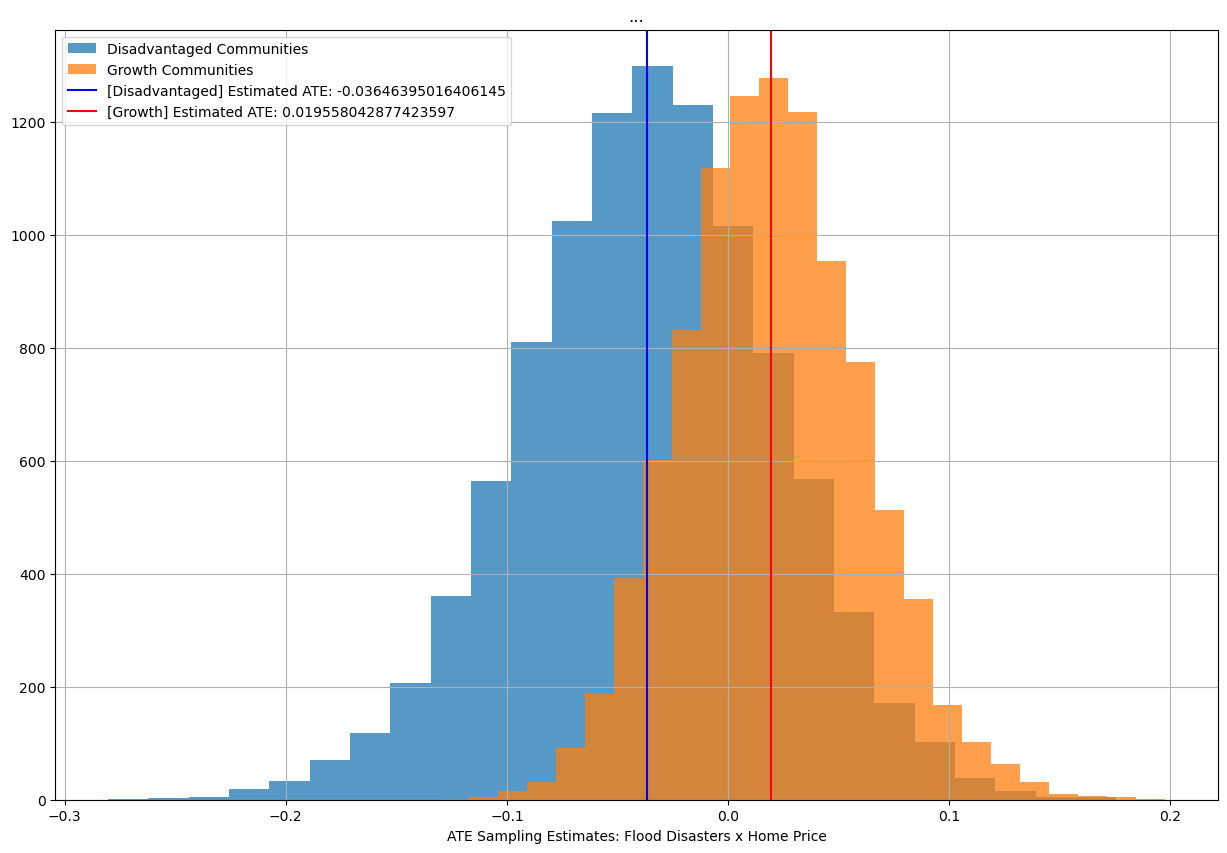

In [87]:
import numpy as np 
import matplotlib.pyplot as plt 

marg = sample.loc[sample['marginalized']==True]['treatment_effect']
nonmarg = sample.loc[sample['marginalized']==False]['treatment_effect']
bootstrapped_sample_marg = \
pd.Series([marg.sample(n=len(marg), replace=True).mean() for _ in np.arange(10000)])
bootstrapped_sample_nonmarg = \
pd.Series([nonmarg.sample(n=len(marg), replace=True).mean() for _ in np.arange(10000)])

plt.rcParams['figure.figsize']=(15,10)
bootstrapped_sample_marg.hist(alpha=0.75,bins=25,label='Disadvantaged Communities')
bootstrapped_sample_nonmarg.hist(alpha=0.75,bins=25,label='Growth Communities')
plt.title('...')
plt.xlabel('ATE Sampling Estimates: Flood Disasters x Home Price')
plt.axvline(marg.mean(),color='blue',label=f'[Disadvantaged] Estimated ATE: {marg.mean()}')
plt.axvline(nonmarg.mean(),color='red',label=f'[Growth] Estimated ATE: {nonmarg.mean()}')
plt.legend()
plt.show() 


In [ ]:
from scipy import stats

t_statistic,p_value = stats.ttest_ind(bootstrapped_sample_marg,bootstrapped_sample_nonmarg,equal_var=True)

In [88]:
msa = pd.read_csv('../scripts/climate_causal_model/outputs/model_w_census_MSAsigreport_pairwise.csv')

msa.head()

,Unnamed: 0,Region,ATE_disadvantaged,ATE_nondisadvantaged,t_statistic,p_value
0,0,"Miami, FL",-0.030993,-0.066574,64.531577,0.000000e+00
1,1,"Tampa, FL",-0.040482,0.001813,-136.641020,0.000000e+00
2,2,"Houston, TX",-0.039261,-0.027412,-39.731223,0.000000e+00
3,3,"New Orleans, LA",-0.039284,0.019171,-83.402033,0.000000e+00
4,4,"New York, NY",-0.017243,-0.025334,27.984430,4.506985e-169
